In [1]:
%load_ext autoreload
%autoreload 2

from trees.data import Data
from trees.causal_tree import CT


data = Data()
data.generate(n=10000, seed=42)
data.generate_random_condition(min_s=0.3, max_s=0.8)
data.set_overlap_measure(overlap_measure="jaccard_distance")

In [2]:
ct = CT(data, on="D")
ct.fit()
ct.scan()
ct.scores

[{'condition': 'feature_0 <= -1.656',
  't_est': 1.417,
  'overlap': 0.05,
  'T0': 1.52,
  'T1': 0.1,
  'depth': 1,
  'rows': 530,
  'selectivity': 0.053,
  'selectivity_to_P_ratio': 0.09075342465753425},
 {'condition': 'feature_0 <= -1.656 AND feature_8 <= 0.684',
  't_est': 1.389,
  'overlap': 0.037,
  'T0': 1.54,
  'T1': 0.15,
  'depth': 2,
  'rows': 388,
  'selectivity': 0.0388,
  'selectivity_to_P_ratio': 0.06643835616438357},
 {'condition': 'feature_0 <= -1.656 AND feature_8 <= 0.684 AND feature_1 <= -0.661',
  't_est': 2.536,
  'overlap': 0.01,
  'T0': 1.9,
  'T1': -0.64,
  'depth': 3,
  'rows': 106,
  'selectivity': 0.0106,
  'selectivity_to_P_ratio': 0.018150684931506848},
 {'condition': 'feature_0 <= -1.656 AND feature_8 <= 0.684 AND feature_1 > -0.661',
  't_est': 0.943,
  'overlap': 0.027,
  'T0': 1.42,
  'T1': 0.47,
  'depth': 3,
  'rows': 282,
  'selectivity': 0.0282,
  'selectivity_to_P_ratio': 0.048287671232876715},
 {'condition': 'feature_0 <= -1.656 AND feature_8 <= 0

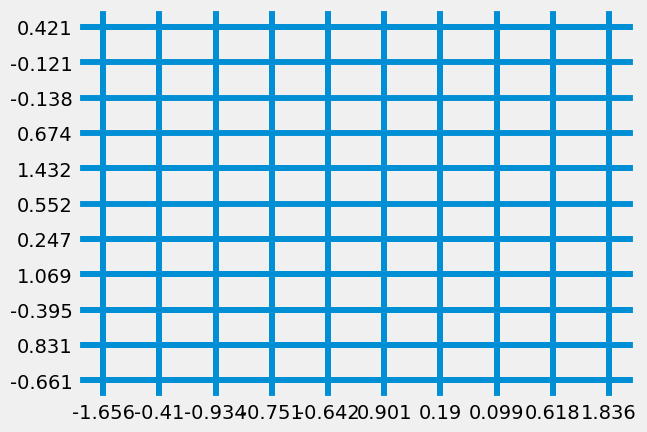

In [21]:
import matplotlib.pyplot as plt
import numpy as np
# Create a new figure
plt.figure()

for s in ct.scores:
    cond = s['condition'].split(" AND ")
    # if feature_0 or feature_1 in included as string in any cond
    for c in cond:
        if 'feature_0' in c :
            # get the numerical value of the condition feature_0 <= -1.656
            if '<=' in c:
                n=  c.split(" <= ")[1]
            else:
                n = c.split(" > ")[1]
            plt.axvline(x=n)
        if 'feature_1' in c :
            if '<=' in c:
                n=c.split(" <= ")[1]
            else:
                n=c.split(" > ")[1]
            plt.axhline(y=n)

plt.show()

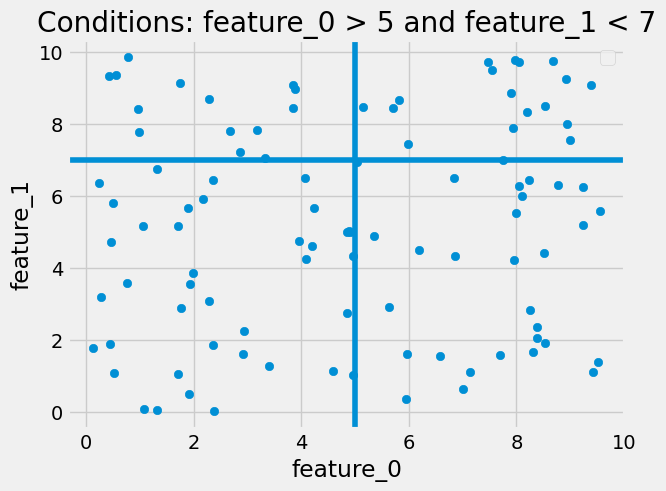

In [8]:


# Create a new figure
plt.figure()

# Plot the vertical line for feature_0 > 5
plt.axvline(x=5)

# Plot the horizontal line for feature_1 < 7
plt.axhline(y=7)

# Add some points to visualize feature_0 and feature_1
# This is optional, just to visualize some data points
feature_0 = np.random.uniform(0, 10, 100)
feature_1 = np.random.uniform(0, 10, 100)
plt.scatter(feature_0, feature_1)

# Set labels and title
plt.xlabel('feature_0')
plt.ylabel('feature_1')
plt.title('Conditions: feature_0 > 5 and feature_1 < 7')

# Add a legend
plt.legend()

# Display the plot
plt.show()


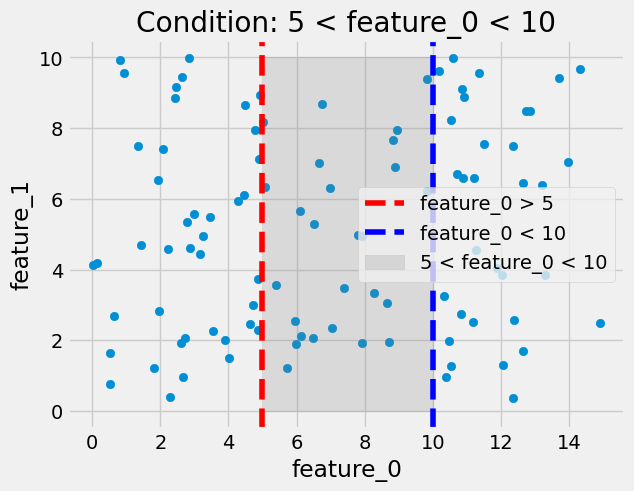

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Create a new figure
plt.figure()

# Plot the vertical lines for feature_0 > 5 and feature_0 < 10
plt.axvline(x=5, color='r', linestyle='--', label='feature_0 > 5')
plt.axvline(x=10, color='b', linestyle='--', label='feature_0 < 10')

# Add some points to visualize feature_0 and feature_1 (optional)
feature_0 = np.random.uniform(0, 15, 100)
feature_1 = np.random.uniform(0, 10, 100)
plt.scatter(feature_0, feature_1)

# Highlight the region where feature_0 is between 5 and 10
plt.fill_betweenx([0, 10], 5, 10, color='gray', alpha=0.2, label='5 < feature_0 < 10')

# Set labels and title
plt.xlabel('feature_0')
plt.ylabel('feature_1')
plt.title('Condition: 5 < feature_0 < 10')

# Add a legend
plt.legend()

# Display the plot
plt.show()
